In [4]:
from google.colab import files

uploaded = files.upload()

Saving model.joblib to model.joblib


In [5]:
import os

MODEL_PATH = "/content/model.joblib"

print(os.path.exists(MODEL_PATH))

True


In [7]:
print(models)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['culmen_length_mm',
                                                   'culmen_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                        

In [10]:
import joblib

models = joblib.load("models_part2.joblib")

print(type(models))
print(models.keys())

<class 'dict'>
dict_keys(['Baseline', 'LogisticRegression', 'KNN', 'SVM', 'GradientBoosting'])


In [14]:
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [11]:
import pandas as pd

df = pd.read_csv("/content/penguins_size.csv")

print(df.shape)
display(df.head())

(344, 7)


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [13]:
display(df.describe(include="all"))

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,334
unique,3,3,NaN,NaN,NaN,NaN,3
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,MALE
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


In [15]:
TARGET = "species"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(X.shape)
print(y.shape)

(344, 6)
(344,)


In [16]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(X_test.shape)

(69, 6)


In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['Adelie' 'Chinstrap' 'Gentoo']


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_encoded, y_pred),
        "Precision": precision_score(
            y_test_encoded,
            y_pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test_encoded,
            y_pred,
            average="weighted"
        ),
        "F1": f1_score(
            y_test_encoded,
            y_pred,
            average="weighted"
        )
    })

comparison_df = (
    pd.DataFrame(results)
      .sort_values("F1", ascending=False)
      .reset_index(drop=True)
)

display(comparison_df)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression,1.000000,1.000000,1.000000,1.000000
1,SVM,1.000000,1.000000,1.000000,1.000000
2,KNN,1.000000,1.000000,1.000000,1.000000
3,GradientBoosting,1.000000,1.000000,1.000000,1.000000
4,Baseline,0.434783,0.189036,0.434783,0.263505


In [19]:
print(type(models))
print(models)

<class 'dict'>
{'Baseline': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['culmen_length_mm',
                                                   'culmen_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
            

In [20]:
print(type(models["LogisticRegression"]))

print(models["LogisticRegression"])

print(models["LogisticRegression"].predict(X_test[:5]))

print(y_test.iloc[:5].tolist())

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['culmen_length_mm',
                                                   'culmen_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
    

In [21]:
best_model_name = comparison_df.iloc[0]["Model"]

print("Best model:", best_model_name)

best_model = models[best_model_name]

Best model: LogisticRegression


In [22]:
y_pred = best_model.predict(X_test)

print(y_pred[:10])

[0 0 2 2 1 0 1 2 1 1]


In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)

cm

array([[30,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 25]])

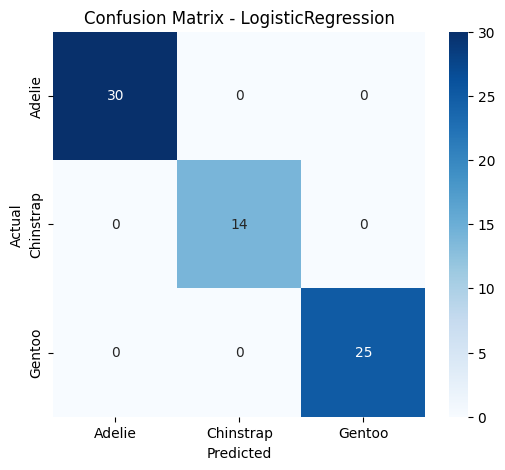

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

In [26]:
comparison_df.to_csv(
    "evaluation.csv",
    index=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression,1.000000,1.000000,1.000000,1.000000
1,SVM,1.000000,1.000000,1.000000,1.000000
2,KNN,1.000000,1.000000,1.000000,1.000000
3,GradientBoosting,1.000000,1.000000,1.000000,1.000000
4,Baseline,0.434783,0.189036,0.434783,0.263505


In [27]:
import joblib

joblib.dump(
    best_model,
    "model.joblib"
)

print("Saved:", best_model_name)

Saved: LogisticRegression


In [28]:
import json

metadata = {
    "model_name": best_model_name,
    "accuracy": float(comparison_df.iloc[0]["Accuracy"]),
    "precision": float(comparison_df.iloc[0]["Precision"]),
    "recall": float(comparison_df.iloc[0]["Recall"]),
    "f1_score": float(comparison_df.iloc[0]["F1"])
}

with open("metadata.json","w") as f:
    json.dump(metadata,f,indent=4)

metadata

{'model_name': 'LogisticRegression',
 'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1_score': 1.0}

In [29]:
schema = {
    "features":[
        "culmen_length_mm",
        "culmen_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
        "island",
        "sex"
    ],
    "target":"species",
    "classes":label_encoder.classes_.tolist()
}

with open("schema.json","w") as f:
    json.dump(schema,f,indent=4)

schema

{'features': ['culmen_length_mm',
  'culmen_depth_mm',
  'flipper_length_mm',
  'body_mass_g',
  'island',
  'sex'],
 'target': 'species',
 'classes': ['Adelie', 'Chinstrap', 'Gentoo']}

In [30]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)

print("Prediction:", prediction)

print("Species:", label_encoder.inverse_transform(prediction))

Prediction: [0]
Species: ['Adelie']


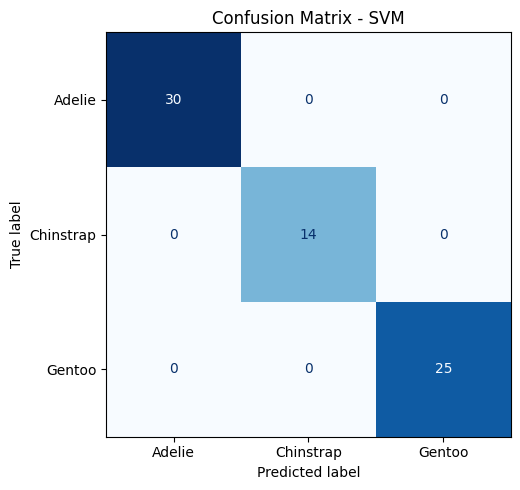

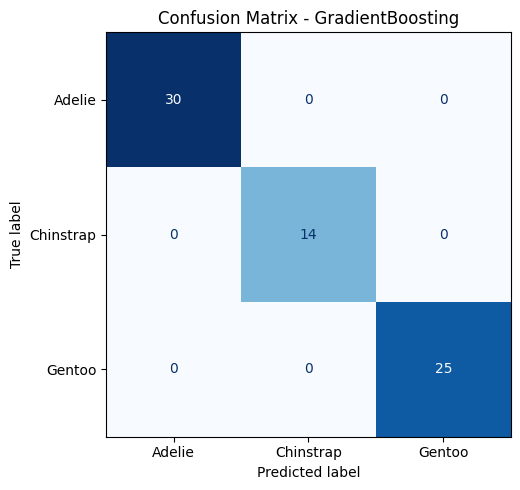

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_to_plot = {
    "SVM": models["SVM"],
    "GradientBoosting": models["GradientBoosting"]
}

for name, model in models_to_plot.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test_encoded,
        y_pred
    )

    fig, ax = plt.subplots(figsize=(6,5))

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    ).plot(
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

In [ ]:
from google.colab import files

files.download("model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("schema.json")
files.download("evaluation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>